In [1]:
import os
import random
import time

import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers


# Seed per la riproducibilità
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Caricamento di CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = (
    keras.datasets.cifar10.load_data()
)


# Trasformazione delle etichette da (n, 1) a (n,)
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()


# Conversione in float32 e normalizzazione tra 0 e 1
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# Creazione del validation set dal training ufficiale
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)


print("Dati preparati correttamente.")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

c:\Users\Msi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Dati preparati correttamente.
x_train: (45000, 32, 32, 3)
y_train: (45000,)
x_val: (5000, 32, 32, 3)
y_val: (5000,)
x_test: (10000, 32, 32, 3)
y_test: (10000,)


In [2]:


def build_mlp():
    return keras.Sequential(
        [
            layers.Input(shape=(32,32,3),name="immagine_input"),

            layers.Flatten(name="Flatten"),
            layers.Dense(units=512,activation="relu",name="dance_512"),
            layers.Dropout(rate=0.40,name="dropou_40t"),
            layers.Dense(units=256,activation="relu"),
            layers.Dropout(rate=0.30,name="dropout_30"),
            layers.Dense(units=10,activation="softmax",name="output")
        ],
        name="mlp_cifar10"
    )

mlp = build_mlp()

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
                                    loss="sparse_categorical_cross_entropy",
                                    metrics=["accuracy"]
    )

mlp.summary()

Model: "mlp_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dance_512 (Dense)               │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropou_40t (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
mlp.compile(

optimizer= keras.optimizers.Adam(learning_rate=0.001),
loss="sparse_categorial_crossentropy",
metrics=["accuracy"]
)

print("MLP compilata correttamente ")

MLP compilata correttamente 


In [4]:
from tensorflow import keras

mlp.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ],
)

print("Modello ricompilato correttamente.")
print("Loss:", mlp.loss)

Modello ricompilato correttamente.
Loss: <LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x00000184B4BFD3A0>, kwargs={'from_logits': False, 'ignore_class': None, 'axis': -1})>


In [5]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=r"C:\Users\Msi\Desktop\machine-learing\models\best_mlp.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Callback configurate.")

Callback configurate.


In [6]:
import time

start_time = time.perf_counter()


history_mlp = mlp.fit(
    x_train,
    y_train,
    validation_data=(x_val,y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping,
               checkpoint,
               reduce_lr
               ],
               verbose=2
)

training_time_mlp= time.perf_counter() - start_time

print("/nAddestramento completato")

Epoch 1/50

Epoch 1: val_loss improved from None to 1.95280, saving model to C:\Users\Msi\Desktop\machine-learing\models\best_mlp.keras

Epoch 1: finished saving model to C:\Users\Msi\Desktop\machine-learing\models\best_mlp.keras
704/704 - 6s - 8ms/step - accuracy: 0.2198 - loss: 2.0949 - val_accuracy: 0.3002 - val_loss: 1.9528 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.95280 to 1.91627, saving model to C:\Users\Msi\Desktop\machine-learing\models\best_mlp.keras

Epoch 2: finished saving model to C:\Users\Msi\Desktop\machine-learing\models\best_mlp.keras
704/704 - 5s - 7ms/step - accuracy: 0.2563 - loss: 1.9854 - val_accuracy: 0.3098 - val_loss: 1.9163 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 1.91627 to 1.91204, saving model to C:\Users\Msi\Desktop\machine-learing\models\best_mlp.keras

Epoch 3: finished saving model to C:\Users\Msi\Desktop\machine-learing\models\best_mlp.keras
704/704 - 5s - 7ms/step - accuracy: 0.2794 - loss: 1.939

In [7]:
import numpy as np

best_val_accuracy_epoch = (
    np.argmax(history_mlp.history["val_accuracy"]) + 1
)

best_val_loss_epoch = (
    np.argmin(history_mlp.history["val_loss"]) + 1
)

best_val_accuracy = max(
    history_mlp.history["val_accuracy"]
)

best_val_loss = min(
    history_mlp.history["val_loss"]
)

print(
    "Migliore epoca per validation accuracy:",
    best_val_accuracy_epoch,
)

print(
    "Migliore validation accuracy:",
    f"{best_val_accuracy:.4f}",
)

print(
    "Migliore epoca per validation loss:",
    best_val_loss_epoch,
)

print(
    "Minore validation loss:",
    f"{best_val_loss:.4f}",
)

Migliore epoca per validation accuracy: 43
Migliore validation accuracy: 0.4136
Migliore epoca per validation loss: 41
Minore validation loss: 1.7127


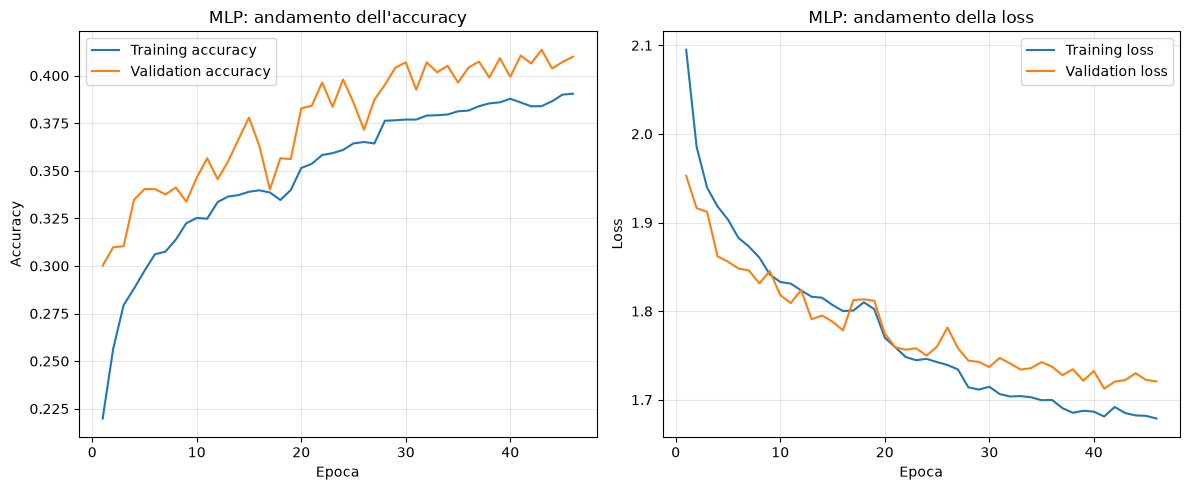

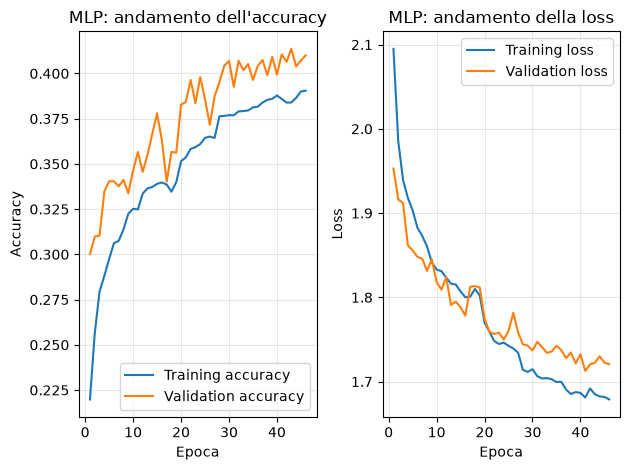

In [8]:
import matplotlib as plt

history = history_mlp.history

epochs_range = range(
    1,
    len(history["loss"]) + 1
)

import matplotlib.pyplot as plt

history = history_mlp.history

epochs_range = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(12, 5))

# Grafico accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["accuracy"], label="Training accuracy")
plt.plot(epochs_range, history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.title("MLP: andamento dell'accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Grafico loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["loss"], label="Training loss")
plt.plot(epochs_range, history["val_loss"], label="Validation loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("MLP: andamento della loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Grafico accuracy
plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    history["accuracy"],
    label="Training accuracy",
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation accuracy",
)

plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.title("MLP: andamento dell'accuracy")
plt.legend()
plt.grid(alpha=0.3)


# Grafico loss
plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    history["loss"],
    label="Training loss",
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation loss",
)

plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("MLP: andamento della loss")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [9]:
final_train_accuracy = history["accuracy"][-1]
final_val_accuracy = history["val_accuracy"][-1]

generalization_gap = (
    final_train_accuracy - final_val_accuracy
)

print(
    "Training accuracy finale:",
    f"{final_train_accuracy:.4f}",
)

print(
    "Validation accuracy finale:",
    f"{final_val_accuracy:.4f}",
)

print(
    "Generalization gap:",
    f"{generalization_gap:.4f}",
)

Training accuracy finale: 0.3905
Validation accuracy finale: 0.4100
Generalization gap: -0.0195


In [10]:
train_accuracy = np.array(
    history_mlp.history["accuracy"]
)

val_accuracy = np.array(
    history_mlp.history["val_accuracy"]
)

train_loss = np.array(
    history_mlp.history["loss"]
)

val_loss = np.array(
    history_mlp.history["val_loss"]
)


# Epoca con massima validation accuracy
best_accuracy_index = np.argmax(val_accuracy)
best_accuracy_epoch = best_accuracy_index + 1

best_val_accuracy = val_accuracy[
    best_accuracy_index
]


# Epoca con minore validation loss
best_loss_index = np.argmin(val_loss)
best_loss_epoch = best_loss_index + 1

minimum_val_loss = val_loss[
    best_loss_index
]


print("RISULTATI MLP")
print("=" * 45)

print(
    f"Migliore validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Epoca migliore per validation accuracy: "
    f"{best_accuracy_epoch}"
)

print()

print(
    f"Minore validation loss: "
    f"{minimum_val_loss:.4f}"
)

print(
    f"Epoca migliore per validation loss: "
    f"{best_loss_epoch}"
)

RISULTATI MLP
Migliore validation accuracy: 0.4136
Epoca migliore per validation accuracy: 43

Minore validation loss: 1.7127
Epoca migliore per validation loss: 41


In [11]:
train_accuracy_at_best_loss = train_accuracy[
    best_loss_index
]

val_accuracy_at_best_loss = val_accuracy[
    best_loss_index
]

gap_at_best_loss = (
    train_accuracy_at_best_loss
    - val_accuracy_at_best_loss
)

print(
    f"Training accuracy all'epoca {best_loss_epoch}: "
    f"{train_accuracy_at_best_loss:.4f}"
)

print(
    f"Validation accuracy all'epoca {best_loss_epoch}: "
    f"{val_accuracy_at_best_loss:.4f}"
)

print(
    f"Gap all'epoca {best_loss_epoch}: "
    f"{gap_at_best_loss:.4f}"
)

Training accuracy all'epoca 41: 0.3859
Validation accuracy all'epoca 41: 0.4106
Gap all'epoca 41: -0.0247


In [12]:
restored_val_loss, restored_val_accuracy = (
    mlp.evaluate(
        x_val,
        y_val,
        verbose=0
    )
)

print(
    f"Validation loss del modello ripristinato: "
    f"{restored_val_loss:.4f}"
)

print(
    f"Validation accuracy del modello ripristinato: "
    f"{restored_val_accuracy:.4f}"
)

Validation loss del modello ripristinato: 1.7127
Validation accuracy del modello ripristinato: 0.4106


In [13]:
import json
import os

os.makedirs(
    r"C:\Users\Msi\Desktop\machine-learing\progetto-cifar-10\results\metrics",
    exist_ok=True
)

mlp_metrics = {
    "model_name": "mlp_cifar10",

    "total_parameters": int(
        mlp.count_params()
    ),

    "epochs_ran": int(
        len(history_mlp.history["loss"])
    ),

    "best_validation_accuracy": float(
        best_val_accuracy
    ),

    "best_accuracy_epoch": int(
        best_accuracy_epoch
    ),

    "minimum_validation_loss": float(
        minimum_val_loss
    ),

    "best_loss_epoch": int(
        best_loss_epoch
    ),

    "restored_validation_accuracy": float(
        restored_val_accuracy
    ),

    "restored_validation_loss": float(
        restored_val_loss
    ),

    "training_accuracy_at_best_loss": float(
        train_accuracy_at_best_loss
    ),

    "validation_accuracy_at_best_loss": float(
        val_accuracy_at_best_loss
    ),

    "gap_at_best_loss": float(
        gap_at_best_loss
    ),

    "batch_size": 64,

    "initial_learning_rate": 0.001
}


with open(
    r"C:\Users\Msi\Desktop\machine-learing\progetto-cifar-10\results\metrics\mlp_metrics.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        mlp_metrics,
        file,
        indent=4
    )


print("Metriche MLP salvate correttamente.")

Metriche MLP salvate correttamente.


In [14]:
import json
import numpy as np
import os

os.makedirs(r"C:\Users\Msi\Desktop\machine-learing\progetto-cifar-10\results\metrics", exist_ok=True)

train_accuracy = np.array(history_mlp.history["accuracy"])
val_accuracy = np.array(history_mlp.history["val_accuracy"])
train_loss = np.array(history_mlp.history["loss"])
val_loss = np.array(history_mlp.history["val_loss"])

best_accuracy_index = np.argmax(val_accuracy)
best_accuracy_epoch = best_accuracy_index + 1
best_val_accuracy = val_accuracy[best_accuracy_index]

best_loss_index = np.argmin(val_loss)
best_loss_epoch = best_loss_index + 1
minimum_val_loss = val_loss[best_loss_index]

train_accuracy_at_best_loss = train_accuracy[best_loss_index]
val_accuracy_at_best_loss = val_accuracy[best_loss_index]

gap_at_best_loss = (
    train_accuracy_at_best_loss
    - val_accuracy_at_best_loss
)

mlp_metrics = {
    "model_name": "mlp_cifar10",
    "total_parameters": int(mlp.count_params()),
    "epochs_ran": int(len(train_loss)),
    "best_validation_accuracy": float(best_val_accuracy),
    "best_accuracy_epoch": int(best_accuracy_epoch),
    "minimum_validation_loss": float(minimum_val_loss),
    "best_loss_epoch": int(best_loss_epoch),
    "restored_validation_loss": float(restored_val_loss),
    "restored_validation_accuracy": float(restored_val_accuracy),
    "training_accuracy_at_best_loss": float(
        train_accuracy_at_best_loss
    ),
    "validation_accuracy_at_best_loss": float(
        val_accuracy_at_best_loss
    ),
    "gap_at_best_loss": float(gap_at_best_loss),
    "batch_size": 64,
    "initial_learning_rate": 0.001
}

with open(
    r"C:\Users\Msi\Desktop\machine-learing\progetto-cifar-10\results\metrics\mlp_metrics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(mlp_metrics, file, indent=4)

print(json.dumps(mlp_metrics, indent=4))

{
    "model_name": "mlp_cifar10",
    "total_parameters": 1707274,
    "epochs_ran": 46,
    "best_validation_accuracy": 0.41359999775886536,
    "best_accuracy_epoch": 43,
    "minimum_validation_loss": 1.7126543521881104,
    "best_loss_epoch": 41,
    "restored_validation_loss": 1.712654709815979,
    "restored_validation_accuracy": 0.4106000065803528,
    "training_accuracy_at_best_loss": 0.38591110706329346,
    "validation_accuracy_at_best_loss": 0.4106000065803528,
    "gap_at_best_loss": -0.024688899517059326,
    "batch_size": 64,
    "initial_learning_rate": 0.001
}
